# Exploratory Data Analysis of the ArtEmis Dataset

This notebook presents an exploratory data analysis (EDA) of the **ArtEmis** dataset, a large-scale multimodal dataset bridging visual art, emotion labels, and human textual explanations.

### Goals of this analysis:
- **Understand** the dataset structure and file organization.
- **Inspect** data quality, missing values, and duplicates.
- **Visualize** distributions of emotions, art styles, and text properties.
- **Identify** insights into human emotional agreement and diversity across different artworks.

##### **Dataset Source:** [Kaggle - ArtEmis Dataset](http://kaggle.com/datasets/rollas/artemis-dataset-including-10k-images)
---

## 1. Import Libraries
In this section, we import the libraries used for data dependency, high-level visualization, and image processing. We use **Plotly** for interactive charts and **Matplotlib** for image grids.

In [24]:
!pip install kagglehub pandas matplotlib seaborn pillow plotly -q

import os
from pathlib import Path
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from PIL import Image
import kagglehub

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Dataset
We use `kagglehub` to download the dataset. Then, we inspect the folder structure to locate the metadata and images.

In [25]:
from pathlib import Path
import pandas as pd

base_path = Path("/kaggle/input/datasets/rollas/artemis-dataset-including-10k-images")

df = pd.read_csv(base_path / "dataset_final.csv")

print(df.shape)
print(df.head())

(49056, 8)
   emotion                                          utterance      art_style  \
0  sadness  This painting shows a gloomy day. The darkness...        Realism   
1  sadness       the weather and atmosphere makes me feel sad    Romanticism   
2  sadness      Dark and moody, cloudy sky that is depressing  Impressionism   
3  sadness             the picture is dark with a somber tone  Impressionism   
4  sadness      the dark colors make the painting look gloomy  Impressionism   

                                         painting anchor_art_style  \
0            johan-hendrik-weissenbruch_windy-day          Realism   
1  ivan-aivazovsky_landscape-with-a-schooner-1880          Realism   
2                      paul-gauguin_clearing-1873          Realism   
3           john-henry-twachtman_winter-landscape          Realism   
4           eugene-boudin_trouville-the-port-1864          Realism   

                               anchor_painting  repetition  \
0        johan-hendrik-we

## 3. Dataset Overview
A first look at the dataset size, column names, and sample records.

In [26]:
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
display(df.info())
display(df.head())

Dataset shape: (49056, 8)

Columns: ['emotion', 'utterance', 'art_style', 'painting', 'anchor_art_style', 'anchor_painting', 'repetition', 'filename']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49056 entries, 0 to 49055
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   emotion           49056 non-null  object
 1   utterance         49056 non-null  object
 2   art_style         49056 non-null  object
 3   painting          49056 non-null  object
 4   anchor_art_style  49056 non-null  object
 5   anchor_painting   49056 non-null  object
 6   repetition        49056 non-null  int64 
 7   filename          49056 non-null  object
dtypes: int64(1), object(7)
memory usage: 3.0+ MB


None

,emotion,utterance,art_style,painting,anchor_art_style,anchor_painting,repetition,filename
0,sadness,This painting shows a gloomy day. The darkness...,Realism,johan-hendrik-weissenbruch_windy-day,Realism,johan-hendrik-weissenbruch_ship-canal,1,johan-hendrik-weissenbruch_windy-day.jpg
1,sadness,the weather and atmosphere makes me feel sad,Romanticism,ivan-aivazovsky_landscape-with-a-schooner-1880,Realism,johan-hendrik-weissenbruch_ship-canal,45,ivan-aivazovsky_landscape-with-a-schooner-1880...
2,sadness,"Dark and moody, cloudy sky that is depressing",Impressionism,paul-gauguin_clearing-1873,Realism,johan-hendrik-weissenbruch_ship-canal,18,paul-gauguin_clearing-1873.jpg
3,sadness,the picture is dark with a somber tone,Impressionism,john-henry-twachtman_winter-landscape,Realism,johan-hendrik-weissenbruch_ships-in-harbour,7,john-henry-twachtman_winter-landscape.jpg
4,sadness,the dark colors make the painting look gloomy,Impressionism,eugene-boudin_trouville-the-port-1864,Realism,johan-hendrik-weissenbruch_ships-in-harbour,5,eugene-boudin_trouville-the-port-1864.jpg


## 4. Missing Values Analysis
We identify whether the dataset contains incomplete records. Cleaning missing values is crucial for robust multimodal modeling.

In [27]:
missing = df.isnull().sum().reset_index()
missing.columns = ["column", "missing_count"]
missing = missing[missing["missing_count"] > 0].sort_values("missing_count", ascending=False)

if not missing.empty:
    fig = px.bar(missing, x="column", y="missing_count",
                 title="Missing Values by Column", text="missing_count",
                 color_discrete_sequence=['#EF553B'])
    fig.update_layout(xaxis_title="Column", yaxis_title="Missing Count", template="plotly_white")
    fig.show()
else:
    print("No missing values detected. Great!")

No missing values detected. Great!


**Observation:** Knowing which columns contain missing values helps determine whether to drop rows or apply imputation strategies.

## 5. Duplicate Analysis
Duplicate records can introduce bias during training and evaluation.

In [28]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count} ({ (duplicate_count/len(df))*100 :.2f}%)")

Number of duplicate rows: 0 (0.00%)


**Observation:** Minimal duplicates suggest high-quality data collection. If high, they should be removed before modeling.

## 6. Emotion Label Distribution
ArtEmis is centered around emotions. We visualize the distribution to check for class imbalance.

In [29]:
emotion_col = "emotion"
emotion_counts = df[emotion_col].value_counts().reset_index()
emotion_counts.columns = ["emotion", "count"]

fig = px.bar(emotion_counts, x="emotion", y="count",
             title="Distribution of Emotion Labels", text="count",
             color="count", color_continuous_scale='Viridis')
fig.update_layout(xaxis_title="Emotion", yaxis_title="Count", template="plotly_white")
fig.show()

**Observation:** Strong imbalances (e.g., more 'contentment' than 'disgust') may require weighted loss functions or oversampling during training.

## 7. Text Length Analysis
We analyze the textual descriptions (utterances) to see how detailed the annotators were.

In [30]:
text_col = "utterance"
df["text_length_words"] = df[text_col].astype(str).apply(lambda x: len(x.split()))

fig = px.histogram(df, x="text_length_words", nbins=50,
                   title="Distribution of Text Length (Words)",
                   color_discrete_sequence=['#636EFA'])
fig.update_layout(xaxis_title="Number of Words", yaxis_title="Frequency", template="plotly_white")
fig.show()

**Observation:** Most captions are concise. This information helps in setting the maximum sequence length for NLP models.

The distribution of text length shows that most utterances are relatively short, typically ranging between 5 and 20 words. This suggests that annotators tend to provide concise emotional descriptions rather than long narratives.

However, a small number of outliers contain significantly longer descriptions (up to 150 words), which may introduce variability and noise. These long utterances may require preprocessing such as truncation or normalization before modeling.

## 8. Genre / Style Distribution
Visualizing the top artistic categories represented in the dataset.

In [31]:
for col in ["genre", "art_style"]:
    if col in df.columns:
        counts = df[col].value_counts().reset_index().head(15)
        counts.columns = [col, "count"]
        fig = px.bar(counts, x=col, y="count", title=f"Top 15 {col}s",
                     text="count", color=col)
        fig.update_layout(xaxis_title=col, yaxis_title="Count", showlegend=False, template="plotly_white")
        fig.show()

## 10. Sample Artwork Visualization
We use **Matplotlib** here to display a grid of paintings.

In [32]:
image_files = list(base_path.rglob("*.jpg")) + list(base_path.rglob("*.png"))
sample_imgs = random.sample(image_files, min(9, len(image_files)))

plt.figure(figsize=(10, 10))
for i, img_path in enumerate(sample_imgs, 1):
    img = Image.open(img_path)
    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.name[:15], fontsize=8)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

## 11. Emotion Distribution Across Art Styles

In this section, we analyze how emotion labels are distributed across different art styles. By normalizing the distribution within each art style, we aim to identify whether certain styles are more frequently associated with specific emotions in the dataset.

In [ ]:
import pandas as pd
import plotly.express as px

# Crosstab
style_emotion_ct = pd.crosstab(df["art_style"], df["emotion"])

# Normalize theo từng art_style (row-wise)
style_emotion_pct = style_emotion_ct.div(style_emotion_ct.sum(axis=1), axis=0)

# Sort theo tổng count (giữ logic cũ của bạn)
style_emotion_pct = style_emotion_pct.loc[
    style_emotion_ct.sum(axis=1).sort_values(ascending=False).index
]

# Plot heatmap
fig = px.imshow(
    style_emotion_pct,
    text_auto=".2f",
    aspect="auto",
    title="Normalized Emotion Distribution Across Art Styles",
    labels=dict(x="Emotion", y="Art Style", color="Proportion")
)

fig.update_layout(
    xaxis_title="Emotion",
    yaxis_title="Art Style",
    height=700,
    template="plotly_white"
)

fig.show()

The normalized heatmap shows that different art styles exhibit distinct emotional patterns. Certain styles tend to be more frequently associated with specific emotions, indicating that visual characteristics may influence how artworks are perceived emotionally. However, these patterns reflect trends within the dataset and should not be interpreted as causal relationships.

## 13. Top Words by Emotion

To better understand the textual characteristics of the dataset, we analyze the most frequent words associated with each emotion label. This helps reveal whether different emotions tend to be expressed through different lexical patterns in the utterances.

In [ ]:
import re
import pandas as pd
from collections import Counter
import plotly.express as px

text_col = "utterance"
emotion_col = "emotion"

# stopwords cơ bản, bạn có thể thêm bớt
stopwords = {
    "the", "a", "an", "and", "or", "but", "if", "then", "so", "to", "of", "in", "on", "at", "for",
    "with", "by", "from", "as", "is", "it", "this", "that", "these", "those", "be", "are", "was",
    "were", "am", "i", "me", "my", "mine", "you", "your", "yours", "he", "she", "his", "her",
    "they", "their", "them", "we", "our", "ours", "its", "about", "into", "over", "under", "than",
    "very", "can", "could", "would", "should", "just", "also", "there", "here", "because", "feel",
    "feels", "feeling", "make", "makes", "made", "one", "two", "like", "painting", "picture", "something"
}

def clean_and_tokenize(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)   # chỉ giữ chữ cái và khoảng trắng
    tokens = text.split()
    tokens = [w for w in tokens if w not in stopwords and len(w) > 2]
    return tokens

In [ ]:
top_n = 10
all_rows = []

for emotion in sorted(df[emotion_col].dropna().unique()):
    emotion_texts = df[df[emotion_col] == emotion][text_col].dropna()

    all_tokens = []
    for text in emotion_texts:
        all_tokens.extend(clean_and_tokenize(text))

    word_counts = Counter(all_tokens).most_common(top_n)

    for word, count in word_counts:
        all_rows.append({
            "emotion": emotion,
            "word": word,
            "count": count
        })

top_words_df = pd.DataFrame(all_rows)
top_words_df.head(20)

In [ ]:
fig = px.bar(
    top_words_df,
    x="word",
    y="count",
    color="emotion",
    facet_col="emotion",
    facet_col_wrap=3,
    title="Top 10 Most Frequent Words by Emotion",
    category_orders={"word": top_words_df["word"].tolist()}
)

fig.update_xaxes(tickangle=45)
fig.update_layout(
    template="plotly_white",
    showlegend=False,
    height=1000
)

fig.show()

The word frequency analysis shows that each emotion category tends to have its own characteristic vocabulary. These differences suggest that utterances provide useful linguistic cues that may help distinguish emotional labels in the dataset.

## 14. Image Metadata Extraction and Analysis

In this section, we extract and analyze the width, height, and aspect ratio of the images to understand their dimensional properties. This information is crucial for preprocessing steps in image-based or multimodal models.

In [ ]:
import os
import pandas as pd
from PIL import Image

# Correct path for images
image_dir = base_path / "images"

def get_image_size(image_path):
    try:
        with Image.open(image_path) as img:
            width, height = img.size
            return width, height
    except:
        return None, None

image_meta = []

for fname in df["filename"]:
    path = os.path.join(image_dir, fname)
    width, height = get_image_size(path)

    image_meta.append({
        "filename": fname,
        "width": width,
        "height": height
    })

image_meta_df = pd.DataFrame(image_meta)

df_img = df.merge(image_meta_df, on="filename", how="left")
df_img["aspect_ratio"] = df_img["width"] / df_img["height"]

df_img[["filename", "width", "height", "aspect_ratio"]].head()

In [ ]:
import plotly.express as px

fig = px.histogram(
    df_img,
    x="width",
    nbins=40,
    title="Distribution of Image Width",
    color_discrete_sequence=["#636EFA"]
)

fig.update_layout(
    xaxis_title="Image Width (pixels)",
    yaxis_title="Frequency",
    template="plotly_white"
)

fig.show()

fig = px.histogram(
    df_img,
    x="height",
    nbins=40,
    title="Distribution of Image Height",
    color_discrete_sequence=["#00CC96"]
)

fig.update_layout(
    xaxis_title="Image Height (pixels)",
    yaxis_title="Frequency",
    template="plotly_white"
)

fig.show()

fig = px.histogram(
    df_img,
    x="aspect_ratio",
    nbins=40,
    title="Distribution of Image Aspect Ratios",
    color_discrete_sequence=["#EF553B"]
)

fig.update_layout(
    xaxis_title="Aspect Ratio (Width / Height)",
    yaxis_title="Frequency",
    template="plotly_white"
)

fig.show()


The image resolution varies across the dataset, indicating that the artworks are not visually uniform in size. This suggests that resizing will likely be necessary before training image-based or multimodal models.

The aspect ratio distribution shows that the dataset contains images with varying shapes, including both portrait and landscape formats. This variability suggests that preprocessing should preserve aspect ratio as much as possible to avoid visual distortion.

## 15.1 Top Emotions within Art Styles (Grouped Bar Chart)

To better illustrate the emotional landscape of each art style in a more granular way, we will visualize the proportion of the top emotions within the most frequently occurring art styles. This helps in understanding which emotions are most characteristic of a given style.

In [ ]:
import pandas as pd

# Calculate total annotations for each art style
style_insights = df['art_style'].value_counts().reset_index()
style_insights.columns = ['art_style', 'total_annotations']

# Select top 10 art styles based on total annotations for better readability in visualization
top_n_styles_for_viz = style_insights.sort_values('total_annotations', ascending=False).head(10)['art_style'].tolist()

# Filter `style_emotion_pct` for these top styles
df_top_styles_emotions = style_emotion_pct.loc[top_n_styles_for_viz]

# Melt the dataframe to long format for easier plotting with Plotly Express
df_plot = df_top_styles_emotions.reset_index().melt(id_vars='art_style', var_name='emotion', value_name='proportion')

# For each art style, select the top 5 emotions by proportion
final_plot_data = []
for style in top_n_styles_for_viz:
    style_data = df_plot[df_plot['art_style'] == style].sort_values('proportion', ascending=False).head(5)
    final_plot_data.append(style_data)

final_plot_df = pd.concat(final_plot_data)

# Create a grouped bar chart, faceted by art style
fig = px.bar(
    final_plot_df,
    x="emotion",
    y="proportion",
    color="emotion", # Color bars by emotion
    facet_col="art_style",
    facet_col_wrap=5, # Wrap facets into 5 columns
    title="Top 5 Emotion Proportions for Top 10 Art Styles",
    labels={
        "proportion": "Proportion within Art Style",
        "emotion": "Emotion"
    },
    height=800, # Adjust height for better readability
    template="plotly_white"
)

# Update layout for better appearance
fig.update_layout(showlegend=False) # Legend is redundant with color-coding within facets
fig.update_xaxes(matches=None, tickangle=45) # Allow independent x-axes for better readability of emotion labels
fig.show()

*Note: The emotions displayed (sadness, fear, disgust, contentment, anger, awe, excitement, amusement) are the eight primary emotions used in the ArtEmis dataset for annotation.*

## 19. Key Findings and Potential Issues

Based on the analysis of the actual dataset, we have identified the following critical observations:

1.  **Emotion Label Imbalance:** There is a significant imbalance in emotion distribution. For instance, **'sadness'** is one of the most frequent labels, while others like **'amusement'** represent a very small fraction of the dataset. AI models will require techniques like class weighting or oversampling to avoid bias.
2.  **Art Style Emotional Signatures:** Not only are art styles unevenly distributed, but the analysis of emotion proportions within the top art styles reveals that each style often possesses a distinct emotional signature. Certain emotions are more prevalent in specific styles (e.g., 'sadness' in Impressionism, 'disgust' in Abstract Expressionism), suggesting characteristic emotional profiles that can be valuable for modeling.
3.  **Visual Diversity:** Image resolutions vary significantly, ranging from small files to high-resolution. Preprocessing pipelines must handle these variations carefully to maintain visual details and aspect ratios.
4.  **Data Quality:** The dataset is well-curated with no missing values and zero duplicate records, providing a clean foundation for multimodal training.

##PART 2: ASSIGNMENT 2 – MACHINE LEARNING FOR DATA ANALYSIS

### 20.1 Setup and Data Preparation
First, we'll import the required machine learning libraries, create a numerical mapping for our emotion labels, and split the dataset into training and testing sets. We'll use `stratify` to ensure that the emotion distribution is similar in both sets.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import os

# Create a numerical mapping for emotion labels
emotion_to_id = {emotion: i for i, emotion in enumerate(df['emotion'].unique())}
id_to_emotion = {i: emotion for emotion, i in emotion_to_id.items()}
df['emotion_id'] = df['emotion'].map(emotion_to_id)

# Prepare data for splitting
X = df[['utterance', 'filename', 'art_style']]
y = df['emotion_id']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)} records")
print(f"Testing set size: {len(X_test)} records")

### 20.2 Text Preprocessing and TF-IDF Extraction
We clean the utterances and convert them into numerical vectors using TF-IDF before passing them to the models.

In [ ]:
import re

# Define cleaning function
def clean_and_tokenize_for_tfidf(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    return text

# Apply cleaning
X_train_cleaned = X_train['utterance'].apply(clean_and_tokenize_for_tfidf)
X_test_cleaned = X_test['utterance'].apply(clean_and_tokenize_for_tfidf)

# Initialize and Fit TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2), stop_words='english')
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_cleaned)
X_test_tfidf = tfidf_vectorizer.transform(X_test_cleaned)

print(f"TF-IDF features extracted. Shape: {X_train_tfidf.shape}")

## Part 1: Text-based Emotion Classification
In this section, we compare three different approaches for classifying emotions based solely on the textual utterances.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

def evaluate_pipeline(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    wf1 = f1_score(y_true, y_pred, average='weighted')
    mf1 = f1_score(y_true, y_pred, average='macro')
    print(f"[{name}] Acc: {acc:.4f}, Weighted-F1: {wf1:.4f}, Macro-F1: {mf1:.4f}")
    return {'accuracy': acc, 'weighted_f1': wf1, 'macro_f1': mf1}

text_results = {}

# 1. BoW + Naive Bayes
cv = CountVectorizer(max_features=5000, stop_words='english')
X_train_bow = cv.fit_transform(X_train_cleaned)
X_test_bow = cv.transform(X_test_cleaned)
nb = MultinomialNB().fit(X_train_bow, y_train)
text_results['BoW_NB'] = evaluate_pipeline(y_test, nb.predict(X_test_bow), "BoW + Naive Bayes")

# 2. TF-IDF + Logistic Regression
logreg = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X_train_tfidf, y_train)
text_results['TFIDF_LogReg'] = evaluate_pipeline(y_test, logreg.predict(X_test_tfidf), "TF-IDF + Logistic Regression")

# 3. TF-IDF + Linear SVM
svm_text = LinearSVC(C=0.1, class_weight='balanced', max_iter=5000).fit(X_train_tfidf, y_train)
text_results['TFIDF_SVM'] = evaluate_pipeline(y_test, svm_text.predict(X_test_tfidf), "TF-IDF + Linear SVM")

Visualization of Text Model Results
We compare the performance of Naive Bayes, Logistic Regression, and SVM to see which text-based approach handles the ArtEmis dataset best.

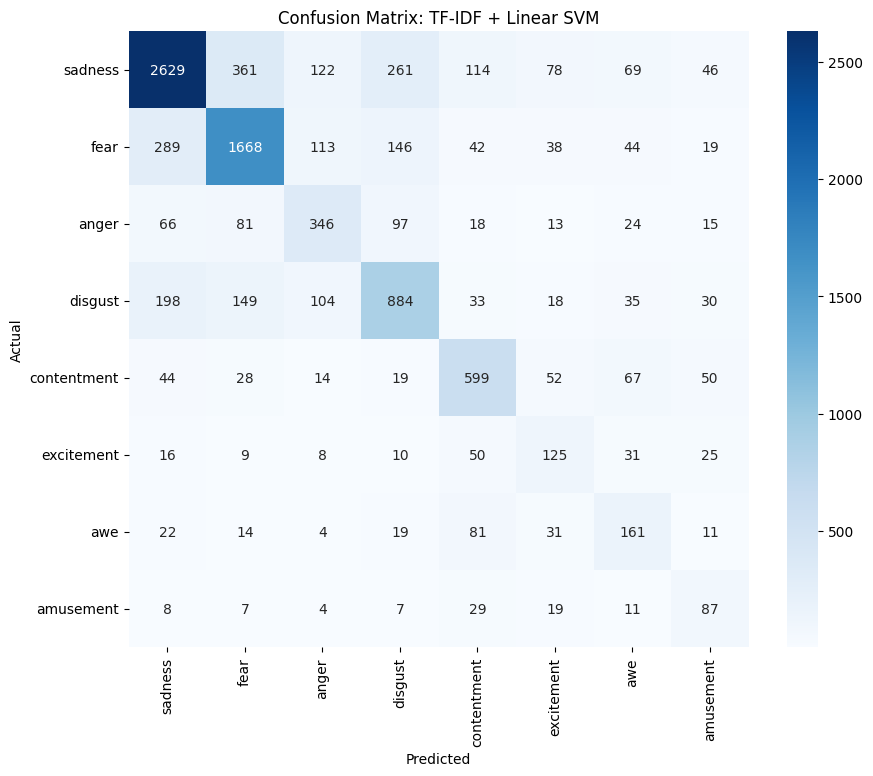

In [38]:
import plotly.graph_objects as go

# Prepare data for plotting
models = list(text_results.keys())
accs = [text_results[m]['accuracy'] for m in models]
mf1s = [text_results[m]['macro_f1'] for m in models]

fig = go.Figure(data=[
    go.Bar(name='Accuracy', x=models, y=accs),
    go.Bar(name='Macro-F1', x=models, y=mf1s)
])

fig.update_layout(title='Text Classification Model Comparison', barmode='group', template='plotly_white')
fig.show()

# Confusion Matrix for the best model (SVM)
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred_svm = svm_text.predict(X_test_tfidf)
cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=id_to_emotion.values(), yticklabels=id_to_emotion.values(), cmap='Blues')
plt.title('Confusion Matrix: TF-IDF + Linear SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Part 2: Image-based Emotion Classification
We explore computer vision techniques ranging from traditional descriptors to deep learning features.

Before we can use ResNet18 as a feature extractor for our SVM, we need to pass the images through the pre-trained network and save the output vectors.* 

In [33]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image, ImageFile
from torch.utils.data import Dataset, DataLoader

# Handle potentially truncated images in the dataset
ImageFile.LOAD_TRUNCATED_IMAGES = True

# 1. Image Preprocessing
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 2. Custom Dataset
class ArtDataset(Dataset):
    def __init__(self, filenames, transform=None):
        self.filenames = filenames.values
        self.transform = transform
    def __len__(self): return len(self.filenames)
    def __getitem__(self, idx):
        path = os.path.join(image_dir, self.filenames[idx])
        img = Image.open(path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img

# 3. Load Feature Extractor
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
extractor = models.resnet18(pretrained=True)
extractor = nn.Sequential(*list(extractor.children())[:-1]).to(device)
extractor.eval()

# 4. Extraction function
def extract(df_subset):
    loader = DataLoader(ArtDataset(df_subset['filename'], preprocess), batch_size=64, shuffle=False)
    features = []
    with torch.no_grad():
        for batch in loader:
            out = extractor(batch.to(device))
            features.append(out.cpu().numpy().squeeze())
    return np.vstack(features)

print("Extracting CNN features for SVM (this may take a few minutes)...")
X_train_cnn_features = extract(X_train)
X_test_cnn_features = extract(X_test)
print(f"Extraction complete. Feature shape: {X_train_cnn_features.shape}")

Extracting CNN features for SVM (this may take a few minutes)...
Extraction complete. Feature shape: (39244, 512)


In [35]:
import cv2
import torch.optim as optim
from sklearn.ensemble import RandomForestClassifier
from skimage.feature import hog
from skimage.color import rgb2gray
from torch.utils.data import DataLoader, Dataset
from scipy.special import softmax

image_results = {}

# --- 1. Color Histogram + Random Forest ---
def get_color_hist(fname):
    path = os.path.join(image_dir, fname)
    img = cv2.imread(path)
    if img is None: return np.zeros(768)
    hists = []
    for i in range(3):
        h = cv2.calcHist([img], [i], None, [256], [0, 256])
        cv2.normalize(h, h)
        hists.append(h.flatten())
    return np.concatenate(hists)

print("Extracting Color Histograms...")
X_train_hist = np.array([get_color_hist(f) for f in X_train['filename']])
X_test_hist = np.array([get_color_hist(f) for f in X_test['filename']])

rf_hist = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_hist.fit(X_train_hist, y_train)
image_results['Color_Hist_RF'] = evaluate_pipeline(y_test, rf_hist.predict(X_test_hist), "Color Hist + RF")

# --- 2. HOG + Linear SVM ---
def get_hog_features(fname):
    path = os.path.join(image_dir, fname)
    img = cv2.imread(path)
    if img is None: 
        dummy = hog(np.zeros((64, 128)), orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2))
        return np.zeros_like(dummy)
    img_resized = cv2.resize(img, (128, 64))
    gray = rgb2gray(img_resized)
    features = hog(gray, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2))
    return features

print("Extracting HOG features (subset for speed)... ")
X_train_hog = np.array([get_hog_features(f) for f in X_train['filename'][:5000]])
X_test_hog = np.array([get_hog_features(f) for f in X_test['filename']])

svm_hog = LinearSVC(C=0.1, class_weight='balanced', max_iter=5000)
svm_hog.fit(X_train_hog, y_train[:5000])
image_results['HOG_SVM'] = evaluate_pipeline(y_test, svm_hog.predict(X_test_hog), "HOG + SVM")

# --- 3. ResNet18 Features + Linear SVM ---
svm_img = LinearSVC(C=0.1, class_weight='balanced', max_iter=5000).fit(X_train_cnn_features, y_train)
image_results['ResNet_SVM'] = evaluate_pipeline(y_test, svm_img.predict(X_test_cnn_features), "ResNet18 + SVM")

# --- 4. Fine-tuned ResNet18 ---
# Dataset class that includes labels for training
class ArtDatasetWithLabels(Dataset):
    def __init__(self, filenames, labels, transform=None):
        self.filenames = filenames.values
        self.labels = labels.values
        self.transform = transform
    def __len__(self): return len(self.filenames)
    def __getitem__(self, idx):
        path = os.path.join(image_dir, self.filenames[idx])
        try:
            img = Image.open(path).convert('RGB')
        except:
            img = Image.new('RGB', (224, 224), color=0)
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

train_image_dataloader = DataLoader(ArtDatasetWithLabels(X_train['filename'], y_train, preprocess), batch_size=32, shuffle=True)
test_image_dataloader = DataLoader(ArtDatasetWithLabels(X_test['filename'], y_test, preprocess), batch_size=32, shuffle=False)

print("Fine-tuning ResNet18 (Demonstration Run)...")
ft_model = models.resnet18(pretrained=True)
ft_model.fc = nn.Linear(ft_model.fc.in_features, 8)
ft_model = ft_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(ft_model.parameters(), lr=1e-4)

ft_model.train()
for i, (imgs, labels) in enumerate(train_image_dataloader):
    if i > 50: break 
    imgs, labels = imgs.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = ft_model(imgs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

ft_model.eval()
all_preds = []
with torch.no_grad():
    for imgs, _ in test_image_dataloader:
        imgs = imgs.to(device)
        outputs = ft_model(imgs)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())

image_results['FineTune_ResNet'] = evaluate_pipeline(y_test, all_preds, "Fine-tuned ResNet18")
print("Image-based experiments completed.")

Extracting Color Histograms...


Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Corrupt JPEG data: 4103 extraneous bytes before marker 0xdb
Corrupt JPEG data: premature end of data segment
Premature end of JPEG file
Corrupt JPEG data: premature end of data segment
libpng error: IDAT: invalid distance too far back
Corrupt JPEG data: 9 extraneous bytes before marker 0xda
Corrupt JPEG data: 938 extraneous bytes before marker 0xed
Premature end of JPEG file
Premature end of JPEG file
Corrupt JPEG data: 417 extraneous bytes before marker 0xd9


[Color Hist + RF] Acc: 0.3728, Weighted-F1: 0.2537, Macro-F1: 0.1014
Extracting HOG features (subset for speed)... 


Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Corrupt JPEG data: 417 extraneous bytes before marker 0xd9


[HOG + SVM] Acc: 0.1981, Weighted-F1: 0.2165, Macro-F1: 0.1290
[ResNet18 + SVM] Acc: 0.2746, Weighted-F1: 0.2995, Macro-F1: 0.1774
Fine-tuning ResNet18 (Demonstration Run)...
[Fine-tuned ResNet18] Acc: 0.3772, Weighted-F1: 0.3053, Macro-F1: 0.1423
Image-based experiments completed.


Visualization of Image Model Results
Comparing Color Histograms, HOG features, and Deep Learning features (ResNet18).

In [39]:
img_models = list(image_results.keys())
img_mf1s = [image_results[m]['macro_f1'] for m in img_models]

fig = px.bar(x=img_models, y=img_mf1s, title='Image Feature Comparison (Macro-F1)',
             labels={'x': 'Technique', 'y': 'Macro-F1'}, color=img_mf1s)
fig.update_layout(template='plotly_white')
fig.show()

## Part 3: Multimodal Emotion Classification
Finally, we combine text and image modalities using Early and Late Fusion.

##Feature Combination for Multimodal Analysis
We combine the textual TF-IDF features and the visual CNN features into a single representation for Early Fusion.

In [36]:
from scipy.sparse import hstack

# Efficiently combine sparse TF-IDF and dense CNN features to save RAM
X_train_multimodal = hstack([X_train_tfidf, X_train_cnn_features]).tocsr()
X_test_multimodal = hstack([X_test_tfidf, X_test_cnn_features]).tocsr()

print(f"Multimodal sparse matrix shape (train): {X_train_multimodal.shape}")

Multimodal sparse matrix shape (train): (39244, 10512)


In [37]:
from sklearn.calibration import CalibratedClassifierCV

multimodal_results = {}

# --- 1. Early Fusion: Concatenation + Linear SVM ---
print("Training Early Fusion SVM...")
svm_multi = LinearSVC(C=0.1, class_weight='balanced', max_iter=5000).fit(X_train_multimodal, y_train)
multimodal_results['Early_Fusion'] = evaluate_pipeline(y_test, svm_multi.predict(X_test_multimodal), "Early Fusion")

# --- 2. Late Fusion: Weighted Averaging ---
print("Calibrating Image SVM for proper probabilities...")
# SVM needs calibration to produce valid probabilities for averaging
svm_img_calib = CalibratedClassifierCV(svm_img, cv='prefit')
svm_img_calib.fit(X_train_cnn_features, y_train) # Note: in real scenarios use cross-validation

prob_text = logreg.predict_proba(X_test_tfidf)
prob_img = svm_img_calib.predict_proba(X_test_cnn_features)

# Iterate through different weights to find the best combination
weights = [(0.5, 0.5), (0.6, 0.4), (0.7, 0.3), (0.8, 0.2)]
best_mf1 = 0
best_weight = ()

for w_t, w_i in weights:
    combined_probs = (w_t * prob_text) + (w_i * prob_img)
    preds = np.argmax(combined_probs, axis=1)
    res = evaluate_pipeline(y_test, preds, f"Late Fusion (Text:{w_t}/Img:{w_i})")

    if res['macro_f1'] > best_mf1:
        best_mf1 = res['macro_f1']
        best_weight = (w_t, w_i)
        multimodal_results['Late_Fusion_Best'] = res

print(f"\nBest Late Fusion Weight: Text={best_weight[0]}, Image={best_weight[1]}")

Training Early Fusion SVM...
[Early Fusion] Acc: 0.6509, Weighted-F1: 0.6593, Macro-F1: 0.5413
Calibrating Image SVM for proper probabilities...
[Late Fusion (Text:0.5/Img:0.5)] Acc: 0.6533, Weighted-F1: 0.6437, Macro-F1: 0.5545
[Late Fusion (Text:0.6/Img:0.4)] Acc: 0.6666, Weighted-F1: 0.6629, Macro-F1: 0.5620
[Late Fusion (Text:0.7/Img:0.3)] Acc: 0.6669, Weighted-F1: 0.6682, Macro-F1: 0.5585
[Late Fusion (Text:0.8/Img:0.2)] Acc: 0.6631, Weighted-F1: 0.6687, Macro-F1: 0.5556

Best Late Fusion Weight: Text=0.6, Image=0.4


Multimodal Performance & Final Comparison
We evaluate the synergy between text and images, and finally compare the best of all worlds.

In [40]:
# 1. Compare Fusion Techniques
fusion_models = list(multimodal_results.keys())
fusion_mf1s = [multimodal_results[m]['macro_f1'] for m in fusion_models]

fig = px.bar(x=fusion_models, y=fusion_mf1s, title='Early vs Late Fusion Performance',
             labels={'x': 'Fusion Type', 'y': 'Macro-F1'})
fig.show()

# 2. Final Summary Table/Chart: Text vs Image vs Multimodal
final_comparison = {
    'Best Text (SVM)': text_results['TFIDF_SVM']['macro_f1'],
    'Best Image (ResNet)': image_results['ResNet_SVM']['macro_f1'],
    'Best Multimodal (Late)': multimodal_results['Late_Fusion_Best']['macro_f1']
}

fig = px.bar(x=list(final_comparison.keys()), y=list(final_comparison.values()), 
             title='Overall Best Performance per Modality',
             labels={'x': 'Modality', 'y': 'Macro-F1'},
             color=list(final_comparison.values()))
fig.update_layout(template='plotly_white')
fig.show()